##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [14]:
# Import libraries
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from torchvision.datasets import OxfordIIITPet
from sklearn.cluster import KMeans

In [ ]:
# Configuration
MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

In [16]:
# Load Oxford-IIIT Pet dataset
dataset = OxfordIIITPet(
    root="data/pets",
    split="test",
    target_types="binary-category",  # 0 = Cat, 1 = Dog
    download=True
)

# Sample a mix of 10 cats and 10 dogs
cat_indices = [i for i in range(len(dataset)) if dataset[i][1] == 0][:10]
dog_indices = [i for i in range(len(dataset)) if dataset[i][1] == 1][:10]
indices = cat_indices + dog_indices

In [19]:
# Extract CLS tokens
@torch.no_grad()
def get_cls(pil_img):
    inputs = processor(images=pil_img.convert("RGB"), return_tensors="pt").to(device)
    out = model(**inputs)
    cls = out.last_hidden_state[:, 0]
    return F.normalize(cls, p=2, dim=1).squeeze().cpu().numpy()

embeddings, true_labels = [], []
for idx in indices:
    img, label = dataset[idx]
    embeddings.append(get_cls(img))
    true_labels.append(label)

X = np.stack(embeddings)  
y = np.array(true_labels)  

In [20]:
# K-Means Clustering 
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
predicted = kmeans.fit_predict(X)

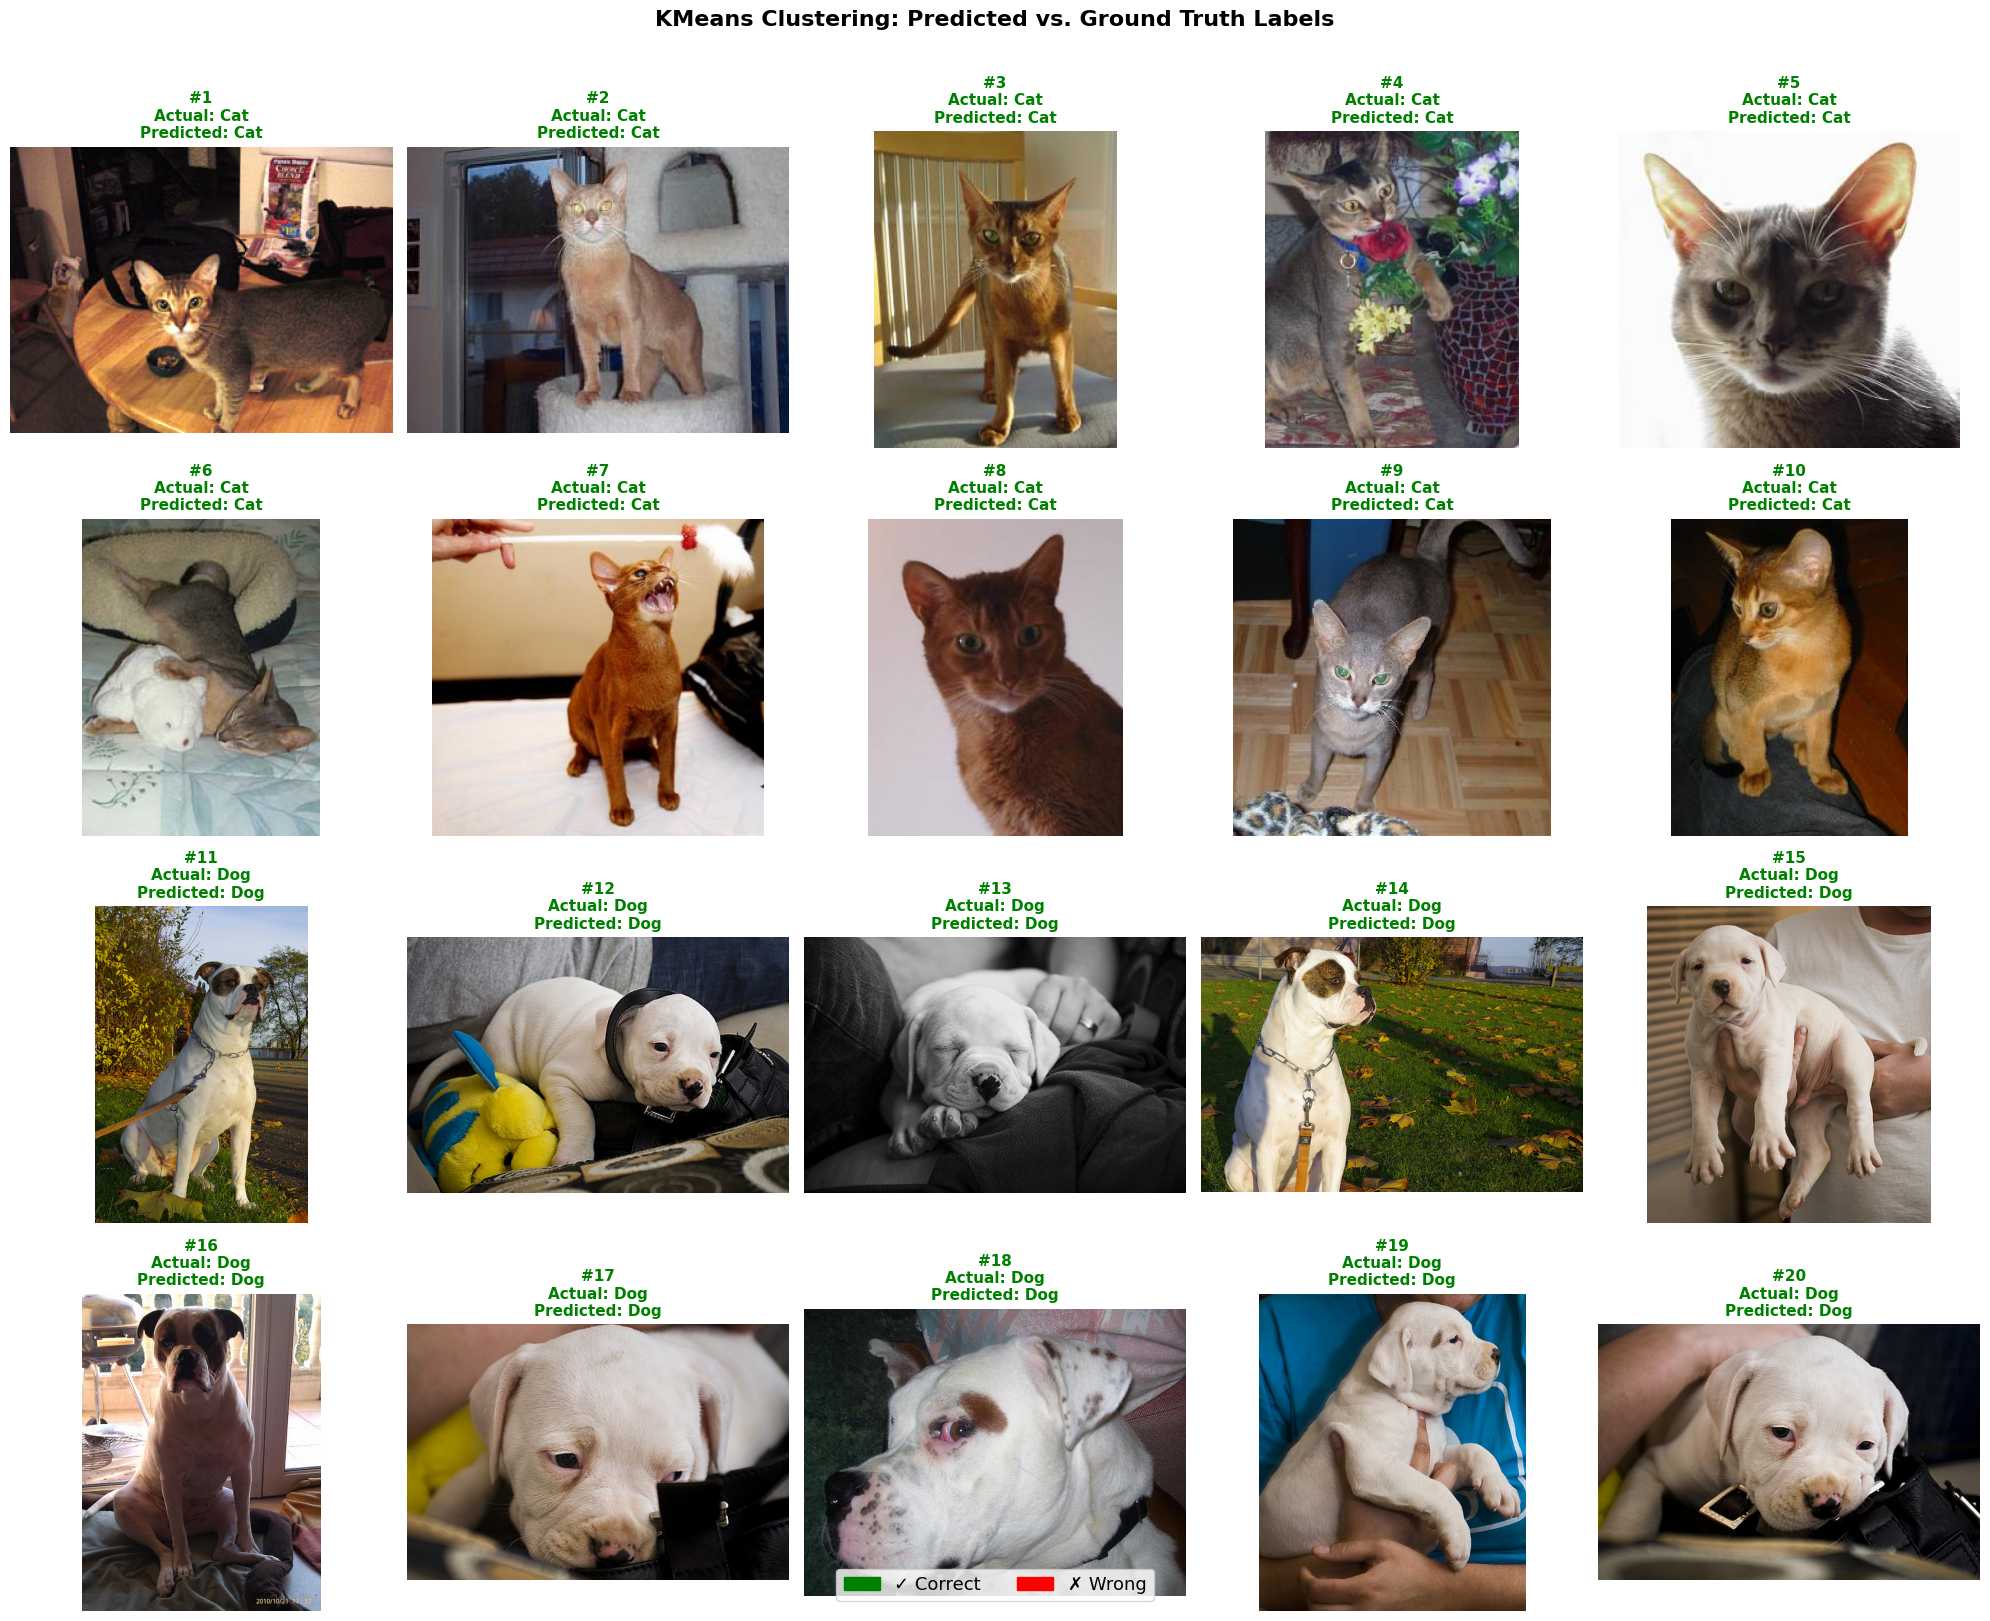

In [ ]:
# Visualize all 20 images 
label_names = {0: "Cat", 1: "Dog"}
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img, _ = dataset[idx]
    true  = label_names[y[i]]
    pred  = label_names[predicted[i]]
    match = true == pred

    axes[i].imshow(img)
    axes[i].axis("off")

    # Green = correct, Red = wrong
    color = "green" if match else "red"
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(5)

    axes[i].set_title(
        f"#{i+1}\nActual: {true}\nPredicted: {pred}",
        fontsize=11,
        color=color,
        fontweight="bold"
    )

# Legend
correct_patch = mpatches.Patch(color="green", label="✓ Correct")
wrong_patch   = mpatches.Patch(color="red",   label="✗ Wrong")
fig.legend(handles=[correct_patch, wrong_patch], loc="lower center",
           ncol=2, fontsize=13, frameon=True, bbox_to_anchor=(0.5, 0.01))

fig.suptitle("KMeans Clustering: Predicted vs. Ground Truth Labels",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [32]:
# Import libraries
import torch
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [ ]:
# Load model and processor
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
classifier = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
classifier.eval()

In [34]:
# Load and preprocess the image
image_path = "/content/lab10-visual-representations/data/golden_retriever.jpg"
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

In [35]:
# Predict the top class
with torch.no_grad():
    logits = classifier(**inputs).logits
    probabilities = logits.softmax(dim=-1)

predicted_id = probabilities.argmax(dim=-1).item()
confidence = probabilities[0, predicted_id].item()
predicted_label = classifier.config.id2label[predicted_id]

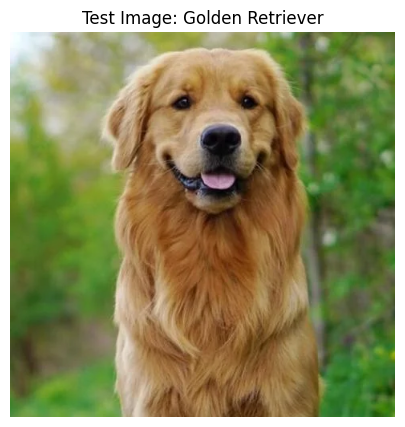

Predicted class: golden retriever
Confidence: 96.44%


In [36]:
# Visualize the image and prediction
plt.figure(figsize=(6, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Test Image: Golden Retriever")
plt.show()

print("Predicted class:", predicted_label)
print("Confidence:", f"{confidence:.2%}")